In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import time
import warnings
warnings.filterwarnings("ignore")

In [ ]:
np.random.seed(42)
n_customers = 300
data = {
    "Annual_Income": np.random.normal(50000, 15000, n_customers),
    "Spending_Score": np.random.normal(50, 25, n_customers),
    "Age": np.random.normal(40, 12, n_customers),
    "Purchase_Frequency": np.random.normal(10, 5, n_customers)
}
df = pd.DataFrame(data)
df["Annual_Income"] = df["Annual_Income"].clip(lower=5000)
df["Spending_Score"] = df["Spending_Score"].clip(lower=1, upper=100)
df["Age"] = df["Age"].clip(lower=18, upper=80)
df["Purchase_Frequency"] = df["Purchase_Frequency"].clip(lower=1)
print("=" * 60)
print("CUSTOMER SEGMENTATION DATASET")
print("=" * 60)
print(df.head())
print("\nDataset Shape:", df.shape)

CUSTOMER SEGMENTATION DATASET
   Annual_Income  Spending_Score        Age  Purchase_Frequency
0   57450.712295       29.275125  49.083863           11.843367
1   47926.035482       35.995474  28.934016            8.033306
2   59715.328072       68.682340  50.435271           10.143724
3   72845.447846       65.259257  56.267654           16.392259
4   46487.699379       49.477460  44.961219           10.955495

Dataset Shape: (300, 4)



PART A: K-MEANS CLUSTERING


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

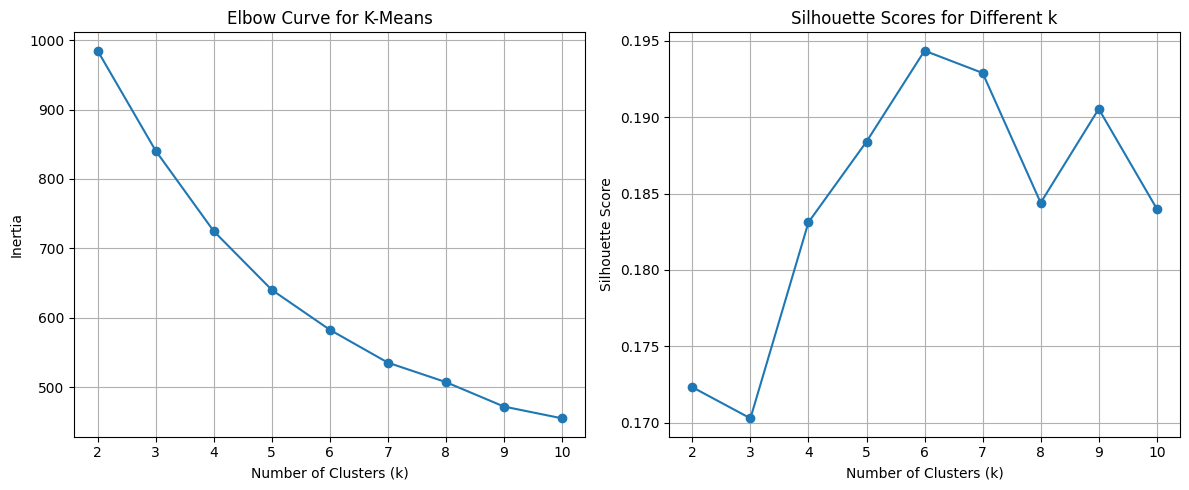

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\n" + "=" * 60)
print("PART A: K-MEANS CLUSTERING")
print("=" * 60)
k_values = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for K-Means")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.grid(True)
plt.tight_layout()
plt.show()

Optimal k based on silhouette score: 6


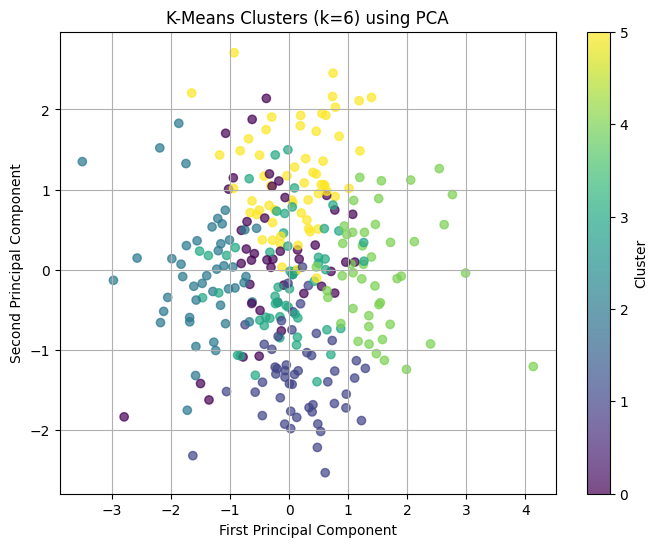

In [ ]:
optimal_k = list(k_values)[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", alpha=0.7)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title(f"K-Means Clusters (k={optimal_k}) using PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


PART B: HIERARCHICAL CLUSTERING


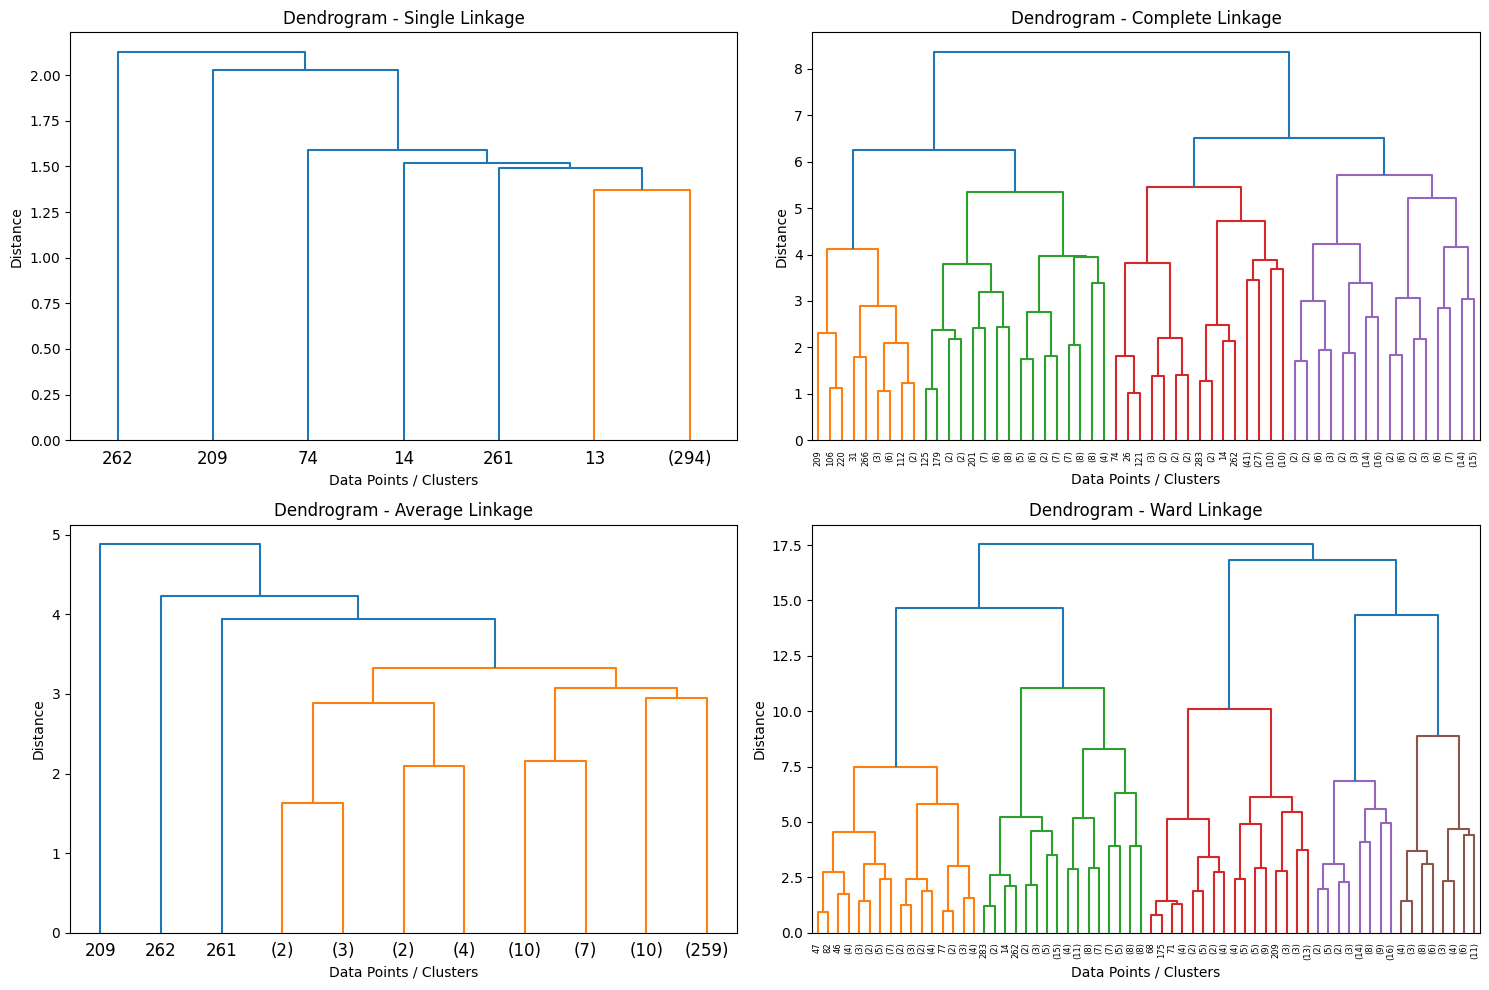

In [ ]:
print("\n" + "=" * 60)
print("PART B: HIERARCHICAL CLUSTERING")
print("=" * 60)
linkage_methods = ["single", "complete", "average", "ward"]
hierarchical_results = {}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
for idx, method in enumerate(linkage_methods):
    linkage_matrix = linkage(X_scaled, method=method)
    dendrogram(linkage_matrix, ax=axes[idx], truncate_mode="level", p=5)
    axes[idx].set_title(f"Dendrogram - {method.capitalize()} Linkage")
    axes[idx].set_xlabel("Data Points / Clusters")
    axes[idx].set_ylabel("Distance")
plt.tight_layout()
plt.show()

Silhouette Scores for Hierarchical Clustering:
Single     Linkage -> Silhouette Score: 0.1336
Complete   Linkage -> Silhouette Score: 0.0815
Average    Linkage -> Silhouette Score: 0.0795
Ward       Linkage -> Silhouette Score: 0.1530


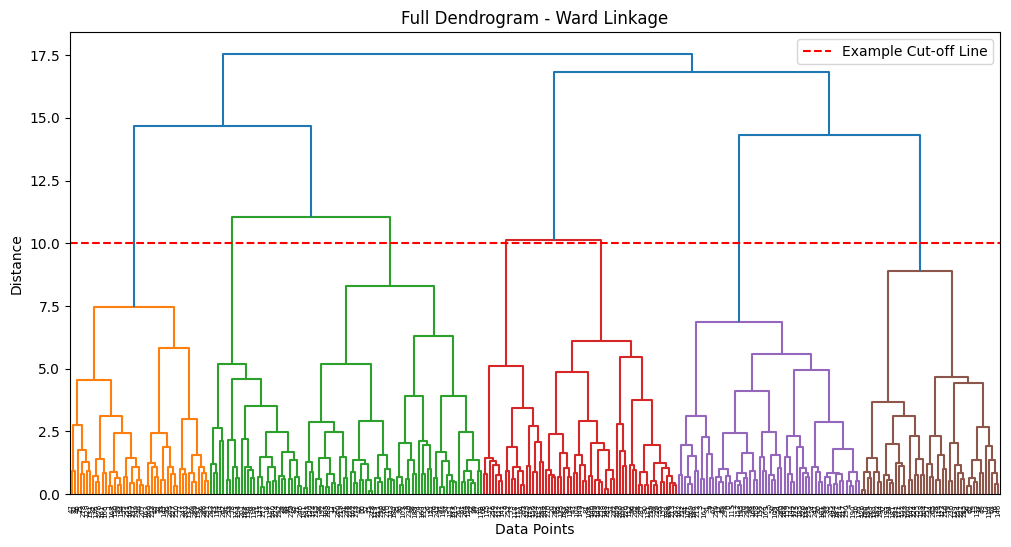

In [ ]:
print("Silhouette Scores for Hierarchical Clustering:")
for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    agg_labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, agg_labels)
    hierarchical_results[method] = {
        "labels": agg_labels,
        "silhouette_score": score
    }
    print(f"{method.capitalize():<10} Linkage -> Silhouette Score: {score:.4f}")
plt.figure(figsize=(12, 6))
ward_linkage_matrix = linkage(X_scaled, method="ward")
dendrogram(ward_linkage_matrix)
plt.title("Full Dendrogram - Ward Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.axhline(y=10, color="red", linestyle="--", label="Example Cut-off Line")
plt.legend()
plt.show()


Best Hierarchical Linkage Method: Ward
Best Hierarchical Silhouette Score: 0.1530

Optimal number of clusters from dendrogram:
A reasonable choice is around 6 clusters based on the cut and silhouette result.


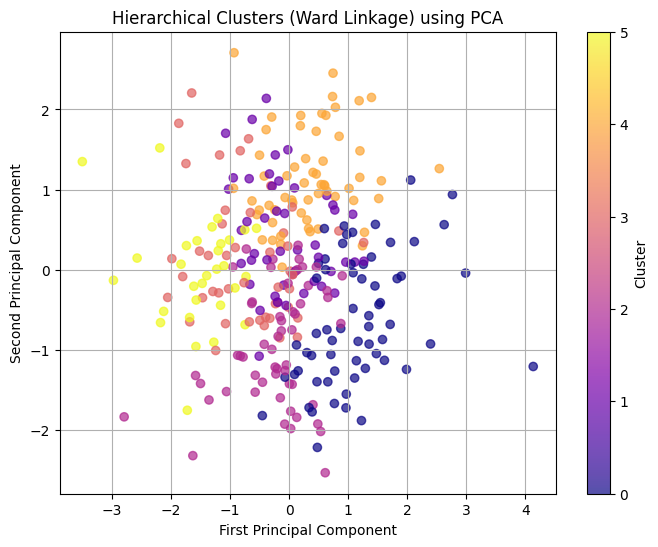

In [ ]:
best_hier_method = max(hierarchical_results, key=lambda x: hierarchical_results[x]["silhouette_score"])
best_hier_score = hierarchical_results[best_hier_method]["silhouette_score"]
best_hier_labels = hierarchical_results[best_hier_method]["labels"]
df["Hierarchical_Cluster"] = best_hier_labels
print(f"\nBest Hierarchical Linkage Method: {best_hier_method.capitalize()}")
print(f"Best Hierarchical Silhouette Score: {best_hier_score:.4f}")
print("\nOptimal number of clusters from dendrogram:")
print(f"A reasonable choice is around {optimal_k} clusters based on the cut and silhouette result.")
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_hier_labels, cmap="plasma", alpha=0.7)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title(f"Hierarchical Clusters ({best_hier_method.capitalize()} Linkage) using PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [ ]:
print("\n" + "=" * 60)
print("PART C: COMPARISON")
print("=" * 60)
print("\nComputation Time Comparison:")
start_time = time.time()
kmeans_test = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_test.fit_predict(X_scaled)
kmeans_time = time.time() - start_time
print(f"K-Means (k={optimal_k}): {kmeans_time:.6f} seconds")
start_time = time.time()
hier_test = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_hier_method)
hier_test.fit_predict(X_scaled)
hierarchical_time = time.time() - start_time
print(f"Hierarchical ({best_hier_method.capitalize()}, k={optimal_k}): {hierarchical_time:.6f} seconds")
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
hier_sil = silhouette_score(X_scaled, best_hier_labels)
print("\nClustering Quality Comparison:")
print(f"K-Means Silhouette Score:        {kmeans_sil:.4f}")
print(f"Hierarchical Silhouette Score:   {hier_sil:.4f}")
if kmeans_sil > hier_sil:
    print("K-Means performs better based on silhouette score.")
elif hier_sil > kmeans_sil:
    print("Hierarchical clustering performs better based on silhouette score.")
else:
    print("Both methods perform similarly based on silhouette score.")
print("\nK-Means Cluster Characteristics:")
kmeans_characteristics = df.groupby("KMeans_Cluster")[["Annual_Income", "Spending_Score", "Age", "Purchase_Frequency"]].mean()
print(kmeans_characteristics)
print("\nHierarchical Cluster Characteristics:")
hier_characteristics = df.groupby("Hierarchical_Cluster")[["Annual_Income", "Spending_Score", "Age", "Purchase_Frequency"]].mean()
print(hier_characteristics)


PART C: COMPARISON

Computation Time Comparison:
K-Means (k=6): 0.089070 seconds
Hierarchical (Ward, k=6): 0.005488 seconds

Clustering Quality Comparison:
K-Means Silhouette Score:        0.1944
Hierarchical Silhouette Score:   0.1530
K-Means performs better based on silhouette score.

K-Means Cluster Characteristics:
                Annual_Income  Spending_Score        Age  Purchase_Frequency
KMeans_Cluster                                                              
0                31718.688714       50.935711  40.613745           14.508797
1                58092.105200       73.330009  32.416912           11.901370
2                42964.474533       69.810474  46.053046            4.898508
3                46358.351867       29.684891  31.570252            7.470611
4                65526.909787       38.559641  40.364056           15.665702
5                52319.270381       37.564875  54.308958            9.957761

Hierarchical Cluster Characteristics:
                      A

In [ ]:
print("\nBusiness Meaning of K-Means Clusters:")
for cluster_id, row in kmeans_characteristics.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  Average Income: {row['Annual_Income']:.2f}")
    print(f"  Average Spending Score: {row['Spending_Score']:.2f}")
    print(f"  Average Age: {row['Age']:.2f}")
    print(f"  Average Purchase Frequency: {row['Purchase_Frequency']:.2f}")
    if row["Annual_Income"] > df["Annual_Income"].mean() and row["Spending_Score"] > df["Spending_Score"].mean():
        print("  Interpretation: High-value customers (high income, high spending)")
    elif row["Annual_Income"] > df["Annual_Income"].mean() and row["Spending_Score"] <= df["Spending_Score"].mean():
        print("  Interpretation: Wealthy but conservative spenders")
    elif row["Annual_Income"] <= df["Annual_Income"].mean() and row["Spending_Score"] > df["Spending_Score"].mean():
        print("  Interpretation: Active spenders with moderate income")
    else:
        print("  Interpretation: Budget-conscious or low-engagement customers")


Business Meaning of K-Means Clusters:

Cluster 0:
  Average Income: 31718.69
  Average Spending Score: 50.94
  Average Age: 40.61
  Average Purchase Frequency: 14.51
  Interpretation: Active spenders with moderate income

Cluster 1:
  Average Income: 58092.11
  Average Spending Score: 73.33
  Average Age: 32.42
  Average Purchase Frequency: 11.90
  Interpretation: High-value customers (high income, high spending)

Cluster 2:
  Average Income: 42964.47
  Average Spending Score: 69.81
  Average Age: 46.05
  Average Purchase Frequency: 4.90
  Interpretation: Active spenders with moderate income

Cluster 3:
  Average Income: 46358.35
  Average Spending Score: 29.68
  Average Age: 31.57
  Average Purchase Frequency: 7.47
  Interpretation: Budget-conscious or low-engagement customers

Cluster 4:
  Average Income: 65526.91
  Average Spending Score: 38.56
  Average Age: 40.36
  Average Purchase Frequency: 15.67
  Interpretation: Wealthy but conservative spenders

Cluster 5:
  Average Income: 

In [ ]:
print("\nFinal Comparison Summary:")
print("- K-Means is usually faster and works well for compact spherical clusters.")
print("- Hierarchical clustering provides dendrograms, which help visualize cluster merging.")
print("- K-Means is preferred for larger datasets because of better speed.")
print("- Hierarchical clustering is useful when you want cluster structure and relationships.")
print("\nSample Data with Cluster Labels:")
print(df.head())


Final Comparison Summary:
- K-Means is usually faster and works well for compact spherical clusters.
- Hierarchical clustering provides dendrograms, which help visualize cluster merging.
- K-Means is preferred for larger datasets because of better speed.
- Hierarchical clustering is useful when you want cluster structure and relationships.

Sample Data with Cluster Labels:
   Annual_Income  Spending_Score        Age  Purchase_Frequency  \
0   57450.712295       29.275125  49.083863           11.843367   
1   47926.035482       35.995474  28.934016            8.033306   
2   59715.328072       68.682340  50.435271           10.143724   
3   72845.447846       65.259257  56.267654           16.392259   
4   46487.699379       49.477460  44.961219           10.955495   

   KMeans_Cluster  Hierarchical_Cluster  
0               5                     4  
1               3                     3  
2               5                     4  
3               4                     4  
4         